In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv("Titanic_train.csv")
test_df = pd.read_csv("Titanic_test.csv")

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


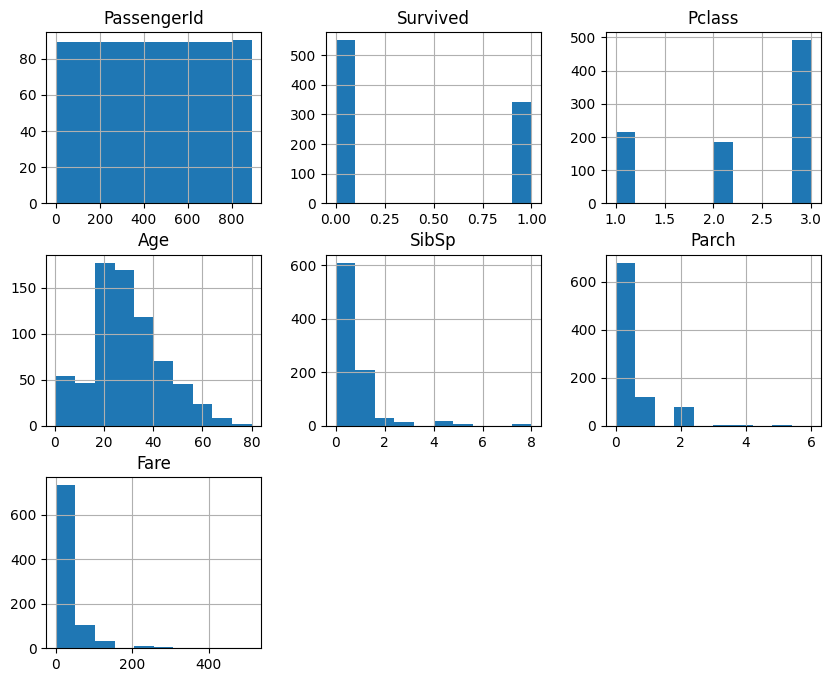

In [6]:
train_df.hist(figsize=(10,8))
plt.show()

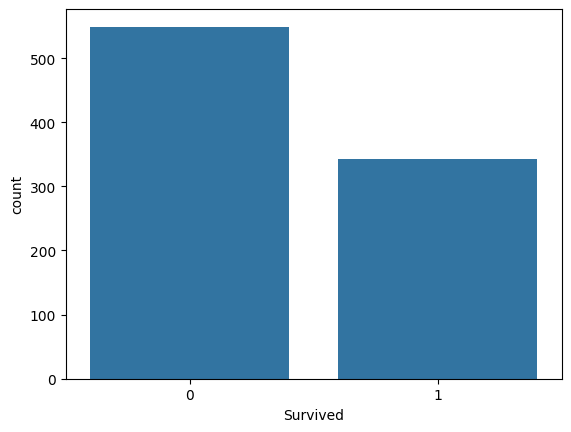

In [7]:
sns.countplot(x='Survived', data=train_df)
plt.show()

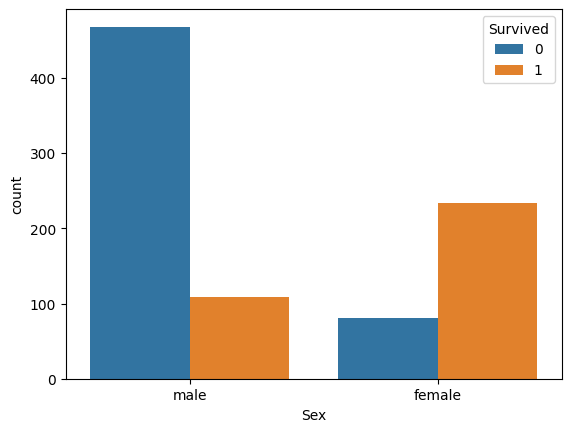

In [8]:
sns.countplot(x='Sex', hue='Survived', data=train_df)
plt.show()

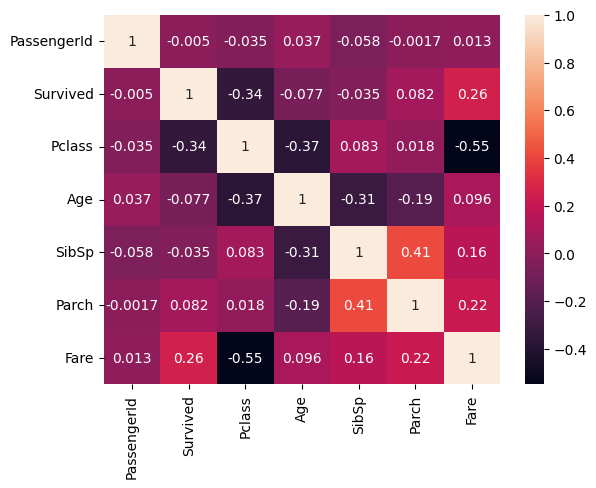

In [9]:
sns.heatmap(train_df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

In [10]:
train_df['Age'].fillna(train_df['Age'].mean(), inplace=True)
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_29015/3485567920.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].mean(), inplace=True)
/tmp/ipykernel_29015/3485567920.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [11]:
train_df = pd.get_dummies(train_df, columns=['Sex','Embarked'], drop_first=True)

In [12]:
X = train_df.drop(['Survived','Name','Ticket','Cabin','PassengerId'], axis=1)

y = train_df['Survived']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))

Accuracy: 0.8100558659217877
Precision: 0.7857142857142857
Recall: 0.7432432432432432
F1 Score: 0.7638888888888888


ROC AUC Score: 0.8817245817245818


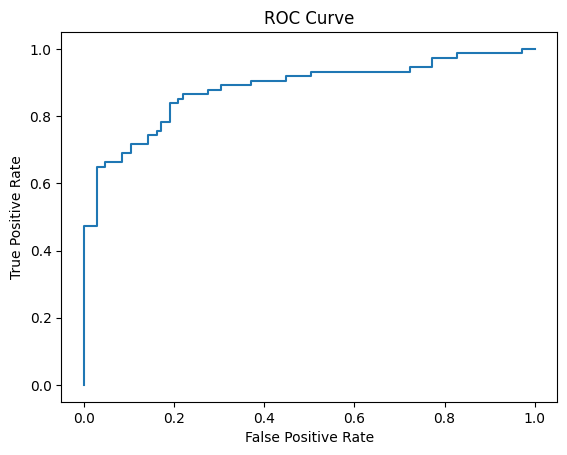

In [17]:
from sklearn.metrics import roc_auc_score, roc_curve
y_prob = model.predict_proba(X_test)[:,1]
roc_score = roc_auc_score(y_test,y_prob)
print("ROC AUC Score:",roc_score)
fpr,tpr,threshold = roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [18]:
coefficients = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_[0]
})
print(coefficients)

      Feature  Coefficient
0      Pclass    -0.941166
1         Age    -0.031366
2       SibSp    -0.297323
3       Parch    -0.111375
4        Fare     0.002547
5    Sex_male    -2.590744
6  Embarked_Q    -0.092396
7  Embarked_S    -0.405880


In [19]:
import pickle

pickle.dump(model, open("titanic_model.pkl", "wb"))

In [20]:
streamlit_code = """
import streamlit as st
import pickle
import numpy as np

# Load trained model
model = pickle.load(open('titanic_model.pkl','rb'))

st.title("Titanic Survival Prediction App")

# User inputs
age = st.number_input("Enter Age")
fare = st.number_input("Enter Fare")

# Prediction button
if st.button("Predict"):

    data = np.array([[age, fare]])

    prediction = model.predict(data)

    if prediction[0] == 1:
        st.success("Passenger Survived")
    else:
        st.error("Passenger Did Not Survive")
"""

In [21]:
with open("app.py","w") as f:
    f.write(streamlit_code)

# Interview Question

1. What is the difference between precision and recall?

Precision measures how accurate the positive predictions are. It tells us how many of the predicted positive cases are actually correct.

Formula: Precision = TP / (TP + FP)
Where TP = True Positive and FP = False Positive.

Example: If the model predicts 10 passengers survived but only 7 actually survived, the precision is 7/10 = 0.7.

Recall measures how many actual positive cases were correctly identified by the model.

Formula: Recall = TP / (TP + FN)
Where FN = False Negative.

Example: If 20 passengers actually survived but the model correctly predicted 15, the recall is 15/20 = 0.75.

Difference:
Precision focuses on the accuracy of positive predictions, while Recall focuses on finding all actual positive cases.


2. What is cross-validation, and why is it important in binary classification?

Cross-Validation is a technique used to evaluate the performance of a machine learning model by dividing the dataset into multiple parts and training/testing the model multiple times.

The most common method is K-Fold Cross-Validation.

Steps:
1. The dataset is divided into K equal parts (folds).
2. The model is trained on K-1 folds.
3. The remaining fold is used for testing.
4. This process is repeated K times, each time using a different fold for testing.
5. The final performance is calculated as the average of all results.

Importance:
- It provides a more reliable evaluation of the model.
- It helps reduce overfitting.
- It ensures the model is tested on different parts of the dataset.
- It improves the generalization ability of the model.
